In [22]:
import pandas as pd
import seaborn as sns
# Set visualization style for consistency and readability
sns.set(style="whitegrid", context="notebook")
# Configure pandas to show more columns when printing dataframes
pd.set_option('display.max_columns', None)

# Load dataset
df = pd.read_csv("diabetes_dataset_with_notes.csv")

# Drop the clinical_notes column
df = df.drop('clinical_notes', axis=1)

# Verify removal
print(df.head())

# Quick overview
print(df.shape)        # rows, columns
print(df.isnull().sum()) # Check missing values
print("Shape of dataset:", df.shape) # Basic shape: How many rows and columns?
print("\nColumn names:")
print(df.columns.tolist()) # Column names: Confirm expected fields and detect hidden spaces
print("\nDataFrame info:") # Data types + non-null count
df.info()
print("\nDuplicate rows:", df.duplicated().sum())  # Quick check for duplicates

   year  gender   age location  race:AfricanAmerican  race:Asian  \
0  2020  Female  32.0  Alabama                     0           0   
1  2015  Female  29.0  Alabama                     0           1   
2  2015    Male  18.0  Alabama                     0           0   
3  2015    Male  41.0  Alabama                     0           0   
4  2016  Female  52.0  Alabama                     1           0   

   race:Caucasian  race:Hispanic  race:Other  hypertension  heart_disease  \
0               0              0           1             0              0   
1               0              0           0             0              0   
2               0              0           1             0              0   
3               1              0           0             0              0   
4               0              0           0             0              0   

  smoking_history    bmi  hbA1c_level  blood_glucose_level  diabetes  
0           never  27.32          5.0                  10

In [23]:
print(df.info())       # column types, nulls
# print(df.head(5))       # first 5 rows

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   year                  100000 non-null  int64  
 1   gender                100000 non-null  object 
 2   age                   100000 non-null  float64
 3   location              100000 non-null  object 
 4   race:AfricanAmerican  100000 non-null  int64  
 5   race:Asian            100000 non-null  int64  
 6   race:Caucasian        100000 non-null  int64  
 7   race:Hispanic         100000 non-null  int64  
 8   race:Other            100000 non-null  int64  
 9   hypertension          100000 non-null  int64  
 10  heart_disease         100000 non-null  int64  
 11  smoking_history       100000 non-null  object 
 12  bmi                   100000 non-null  float64
 13  hbA1c_level           100000 non-null  float64
 14  blood_glucose_level   100000 non-null  int64  
 15  d

Class counts:
diabetes
0    91500
1     8500
Name: count, dtype: int64

Class distribution (%):
diabetes
0    91.5
1     8.5
Name: proportion, dtype: float64


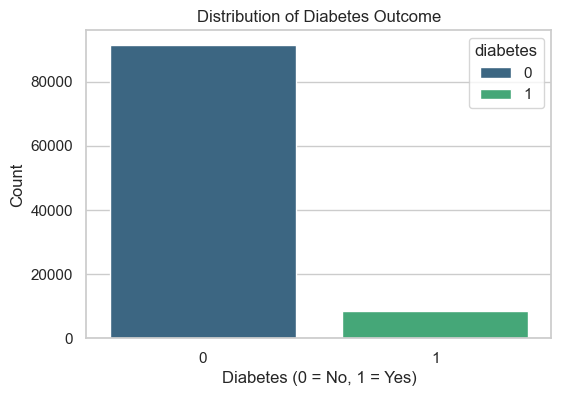

In [24]:
# Why: Understand how balanced the diabetes classes are.
# This determines sampling, metrics, and modeling strategy.
import matplotlib.pyplot as plt 

target_col = "diabetes"   # confirmed from your dataset

# 1. Raw counts
print("Class counts:")
print(df[target_col].value_counts())

# 2. Percentage distribution
print("\nClass distribution (%):")
print(df[target_col].value_counts(normalize=True) * 100)

# 3. Visualize imbalance
plt.figure(figsize=(6,4))
sns.countplot(data=df, x=target_col, hue="diabetes", palette="viridis")
plt.title("Distribution of Diabetes Outcome")
plt.xlabel("Diabetes (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

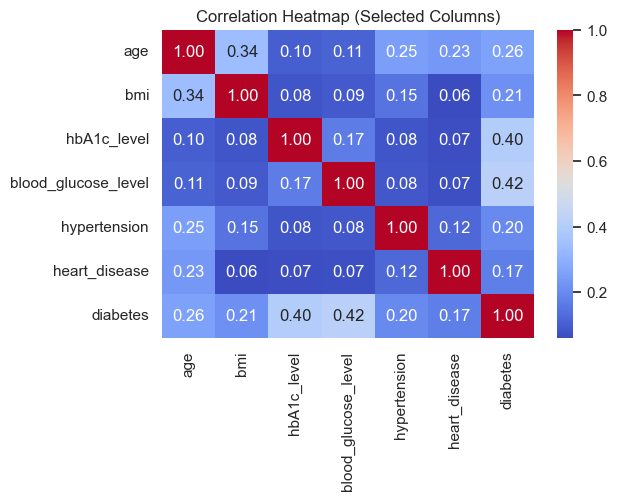

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select specific columns
selected_cols = ['age','bmi','hbA1c_level','blood_glucose_level','hypertension', 'heart_disease','diabetes']
subset_df = df[selected_cols]

# Compute correlation matrix
corr_matrix = subset_df.corr()

# Plot heatmap
plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Selected Columns)")
plt.show()

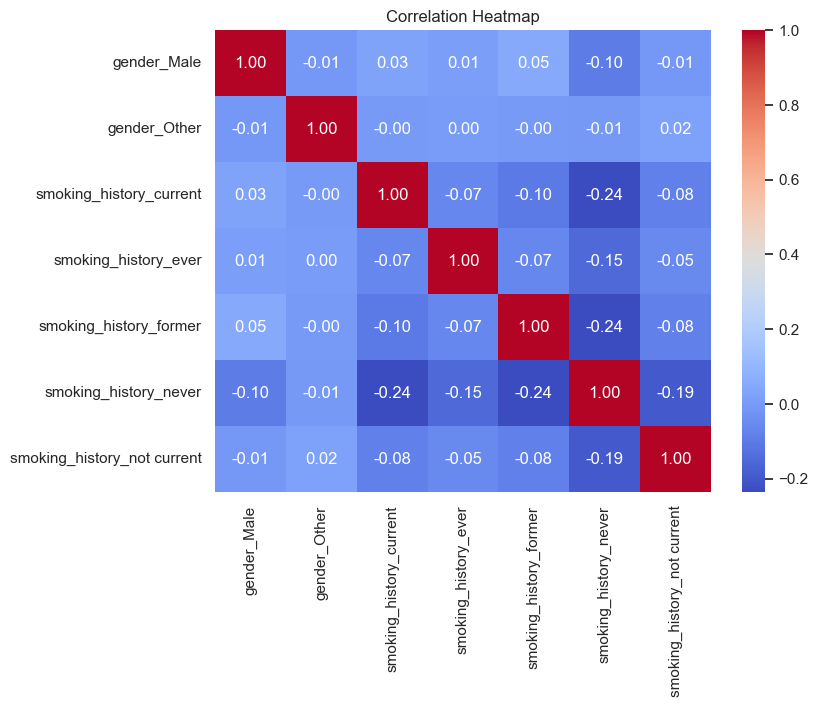

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Example categorical columns in your dataset
categorical_cols = ['gender','smoking_history']

# Encode categorical columns using one-hot
df_encoded = pd.get_dummies(df[categorical_cols], drop_first=True)

# Compute correlation matrix only for categorical features
corr_matrix = df_encoded.corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [27]:
# MISSING VALUES + ZERO-VALUE DIAGNOSTICS
# Why: Identify data quality issues before cleaning & modeling
import numpy as np 

# 1. Missing values summary
print("Missing values per column:")
print(df.isna().sum())

# 2. Check for zero values in numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

zero_counts = (df[numeric_cols] == 0).sum().sort_values(ascending=False)
print("\nZero-value counts in numeric columns:")
print(zero_counts)

# 3. Quick descriptive stats to spot anomalies
print("\nDescriptive statistics:")
display(df.describe())

# 4. Check unique values for categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("\nCategorical columns and unique values:")
for col in categorical_cols:
    print(f"{col}: {df[col].unique()[:10]}")  # show first 10 unique values

Missing values per column:
year                    0
gender                  0
age                     0
location                0
race:AfricanAmerican    0
race:Asian              0
race:Caucasian          0
race:Hispanic           0
race:Other              0
hypertension            0
heart_disease           0
smoking_history         0
bmi                     0
hbA1c_level             0
blood_glucose_level     0
diabetes                0
dtype: int64

Zero-value counts in numeric columns:
heart_disease           96058
hypertension            92515
diabetes                91500
race:Caucasian          80124
race:Hispanic           80112
race:Other              80002
race:Asian              79985
race:AfricanAmerican    79777
year                        0
age                         0
bmi                         0
hbA1c_level                 0
blood_glucose_level         0
dtype: int64

Descriptive statistics:


,year,age,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,bmi,hbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,2018.360820,41.885856,0.202230,0.200150,0.198760,0.19888,0.199980,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,1.345239,22.516840,0.401665,0.400114,0.399069,0.39916,0.399987,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,2015.000000,0.080000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,2019.000000,24.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,2019.000000,43.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,2019.000000,60.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,2022.000000,80.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000



Categorical columns and unique values:
gender: ['Female' 'Male' 'Other']
location: ['Alabama' 'Alaska' 'Arizona' 'Arkansas' 'California' 'Colorado'
 'Connecticut' 'Delaware' 'District of Columbia' 'Florida']
smoking_history: ['never' 'not current' 'current' 'No Info' 'ever' 'former']


In [28]:
# CLEANING STRATEGY DECISIONS
# Why: Identify which numeric columns need zero→NaN conversion
#      and prepare for imputation + encoding.
# ---------------------------------------------------------

# 1. Identify numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns:", numeric_cols)

# 2. Identify columns with impossible zeros
zero_counts = (df[numeric_cols] == 0).sum().sort_values(ascending=False)
print("\nZero counts in numeric columns:")
print(zero_counts)

# 3. Decide which columns treat zero as missing
zero_as_missing = []
for col in numeric_cols:
    # If more than 0 zeros AND zeros are medically impossible
    if zero_counts[col] > 0 and col in ['bmi', 'hbA1c_level', 'blood_glucose_level']:
        zero_as_missing.append(col)

print("\nColumns where zero = missing:", zero_as_missing)

Numeric columns: ['year', 'age', 'race:AfricanAmerican', 'race:Asian', 'race:Caucasian', 'race:Hispanic', 'race:Other', 'hypertension', 'heart_disease', 'bmi', 'hbA1c_level', 'blood_glucose_level', 'diabetes']

Zero counts in numeric columns:
heart_disease           96058
hypertension            92515
diabetes                91500
race:Caucasian          80124
race:Hispanic           80112
race:Other              80002
race:Asian              79985
race:AfricanAmerican    79777
year                        0
age                         0
bmi                         0
hbA1c_level                 0
blood_glucose_level         0
dtype: int64

Columns where zero = missing: []


In [29]:
# CLEANING & PREPARATION PIPELINE
# Why: Prepare the dataset for modeling (encoding + dropping text)
# ---------------------------------------------------------

# Identify categorical columns
categorical_cols = ['gender', 'location', 'smoking_history']

# One-Hot Encode categorical variables
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Confirm all columns are numeric now
print("All numeric:", df_encoded.dtypes.apply(lambda x: x == 'float64' or x == 'int64').all())

# Separate features and target
X = df_encoded.drop(columns=['diabetes'])
y = df_encoded['diabetes']

print("Final feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

# 6. Preview final cleaned dataset
display(df_encoded.head(10))

All numeric: False
Final feature matrix shape: (100000, 73)
Target vector shape: (100000,)


,year,age,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,bmi,hbA1c_level,blood_glucose_level,diabetes,gender_Male,gender_Other,location_Alaska,location_Arizona,location_Arkansas,location_California,location_Colorado,location_Connecticut,location_Delaware,location_District of Columbia,location_Florida,location_Georgia,location_Guam,location_Hawaii,location_Idaho,location_Illinois,location_Indiana,location_Iowa,location_Kansas,location_Kentucky,location_Louisiana,location_Maine,location_Maryland,location_Massachusetts,location_Michigan,location_Minnesota,location_Mississippi,location_Missouri,location_Montana,location_Nebraska,location_Nevada,location_New Hampshire,location_New Jersey,location_New Mexico,location_New York,location_North Carolina,location_North Dakota,location_Ohio,location_Oklahoma,location_Oregon,location_Pennsylvania,location_Puerto Rico,location_Rhode Island,location_South Carolina,location_South Dakota,location_Tennessee,location_Texas,location_United States,location_Utah,location_Vermont,location_Virgin Islands,location_Virginia,location_Washington,location_West Virginia,location_Wisconsin,location_Wyoming,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,2020,32.0,0,0,0,0,1,0,0,27.32,5.0,100,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,2015,29.0,0,1,0,0,0,0,0,19.95,5.0,90,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2,2015,18.0,0,0,0,0,1,0,0,23.76,4.8,160,0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
3,2015,41.0,0,0,1,0,0,0,0,27.32,4.0,159,0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
4,2016,52.0,1,0,0,0,0,0,0,23.75,6.5,90,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
5,2016,66.0,0,0,1,0,0,0,0,27.32,5.7,159,0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
6,2015,49.0,0,0,1,0,0,0,0,24.34,5.7,80,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,Fals

In [30]:
# Convert boolean columns to integers (True→1, False→0)
df_encoded_fixed = df_encoded.copy()
bool_cols = df_encoded_fixed.select_dtypes(include=['bool']).columns.tolist()
df_encoded_fixed[bool_cols] = df_encoded_fixed[bool_cols].astype(int)

print("Boolean columns converted:", bool_cols)

Boolean columns converted: ['gender_Male', 'gender_Other', 'location_Alaska', 'location_Arizona', 'location_Arkansas', 'location_California', 'location_Colorado', 'location_Connecticut', 'location_Delaware', 'location_District of Columbia', 'location_Florida', 'location_Georgia', 'location_Guam', 'location_Hawaii', 'location_Idaho', 'location_Illinois', 'location_Indiana', 'location_Iowa', 'location_Kansas', 'location_Kentucky', 'location_Louisiana', 'location_Maine', 'location_Maryland', 'location_Massachusetts', 'location_Michigan', 'location_Minnesota', 'location_Mississippi', 'location_Missouri', 'location_Montana', 'location_Nebraska', 'location_Nevada', 'location_New Hampshire', 'location_New Jersey', 'location_New Mexico', 'location_New York', 'location_North Carolina', 'location_North Dakota', 'location_Ohio', 'location_Oklahoma', 'location_Oregon', 'location_Pennsylvania', 'location_Puerto Rico', 'location_Rhode Island', 'location_South Carolina', 'location_South Dakota', 'loc

In [31]:
# Train-Test-Split 

from sklearn.model_selection import train_test_split

# Recreate X and y after fixing booleans
X = df_encoded_fixed.drop(columns=['diabetes'])
y = df_encoded_fixed['diabetes']

# Stratified train/test split (CRITICAL due to imbalance)
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

# Check class balance in train/test
print("\nTrain set class distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest set class distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training set shape: (80000, 73)
Test set shape: (20000, 73)

Train set class distribution:
diabetes
0    91.5
1     8.5
Name: proportion, dtype: float64

Test set class distribution:
diabetes
0    91.5
1     8.5
Name: proportion, dtype: float64


# Undersampling Technique

Categorical columns: ['gender', 'location', 'smoking_history']
Before undersampling: diabetes
0    73200
1     6800
Name: count, dtype: int64
After undersampling: diabetes
0    6800
1    6800
Name: count, dtype: int64


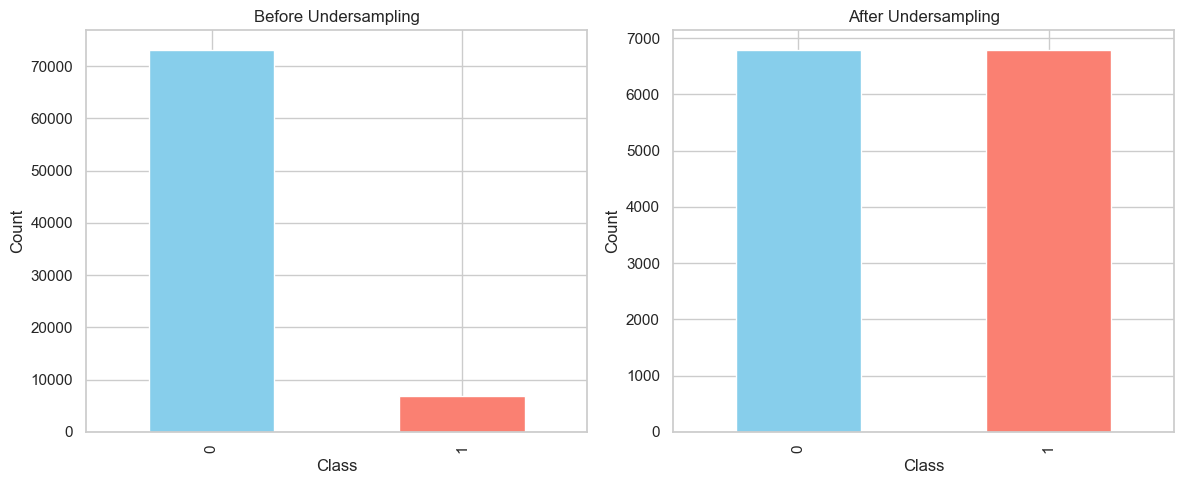

In [46]:
from sklearn.preprocessing import LabelEncoder
from imblearn.under_sampling import RandomUnderSampler

# Separate features and target
X = df.drop('diabetes', axis=1)
y = df['diabetes']

# Identify categorical columns
cat_cols = X.select_dtypes(include="object").columns
print("Categorical columns:", cat_cols.tolist())

# Apply Label Encoding to each categorical column
le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col])

# Train-test split (keep stratification for balance in test set)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Before undersampling:", y_train.value_counts())

# Apply Random Undersampling
rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X_train, y_train)

print("After undersampling:", y_resampled.value_counts())

# Plot before undersampling
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
y_train.value_counts().plot(kind='bar', color=['skyblue','salmon'])
plt.title("Before Undersampling")
plt.xlabel("Class")
plt.ylabel("Count")

# Plot after undersampling
plt.subplot(1,2,2)
y_resampled.value_counts().plot(kind='bar', color=['skyblue','salmon'])
plt.title("After Undersampling")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Confusion Matrix:
 [[16207  2093]
 [  207  1493]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.89      0.93     18300
           1       0.42      0.88      0.56      1700

    accuracy                           0.89     20000
   macro avg       0.70      0.88      0.75     20000
weighted avg       0.94      0.89      0.90     20000

AUC Score : 0.9612801671488268


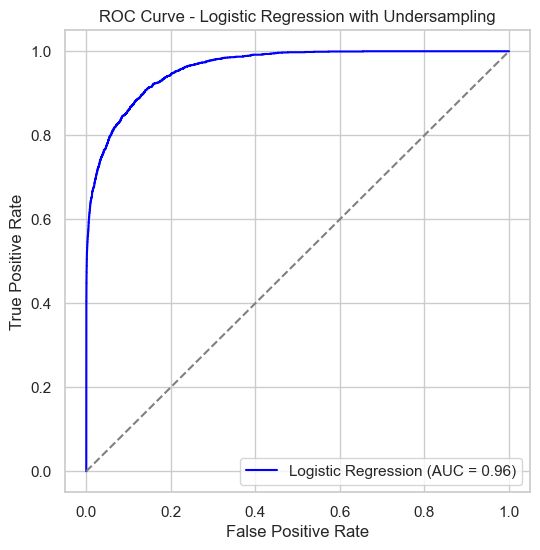

In [44]:
# Train Logistic Regression on Undersampling Data
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score

log_reg = LogisticRegression(max_iter=2000, solver='liblinear')
log_reg.fit(X_resampled, y_resampled)

# Predict probabilities
# Predict test set
y_pred_rus = log_reg.predict(X_test)
y_pred_proba = log_reg.predict_proba(X_test)[:,1]

# Evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rus))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rus))

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)
print("AUC Score :" , auc_score)

# Plot ROC curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc_score:.2f})", color="blue")
plt.plot([0,1],[0,1], linestyle="--", color="gray")  # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression with Undersampling")
plt.legend(loc="lower right")
plt.show()

Confusion Matrix:
 [[14784  3516]
 [   72  1628]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.81      0.89     18300
           1       0.32      0.96      0.48      1700

    accuracy                           0.82     20000
   macro avg       0.66      0.88      0.68     20000
weighted avg       0.94      0.82      0.86     20000

AUC Score : 0.9601261330761812


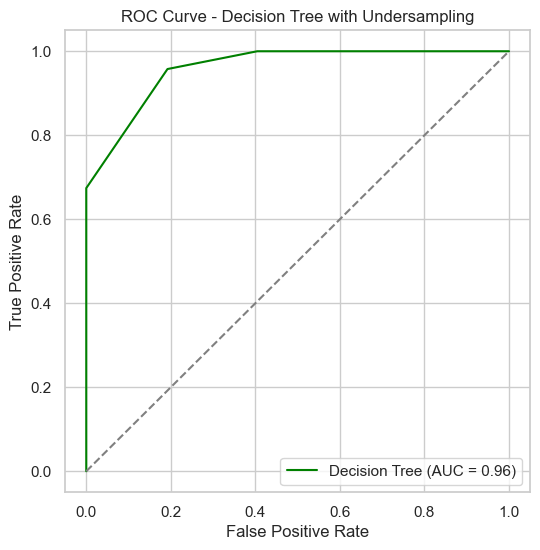

In [45]:
# Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

dt = DecisionTreeClassifier(max_depth=5, criterion="entropy", random_state=42)
dt.fit(X_resampled, y_resampled)

# Predict probabilities
# Predict test set
y_pred_rus = dt.predict(X_test)
y_pred_proba = dt.predict_proba(X_test)[:,1]

# Evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ROC curve + AUC
y_pred_proba = dt.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)
print("AUC Score :" , auc_score)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"Decision Tree (AUC = {auc_score:.2f})", color="green")
plt.plot([0,1],[0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree with Undersampling")
plt.legend(loc="lower right")
plt.show()

In [72]:
# MODEL COMPARISON DASHBOARD
# Why: Summarize all model performances in one table

import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, precision_score

results = {
    "Model": [
        "Logistic Regression",
        "Decision Tree",
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_rus),
        accuracy_score(y_test, y_pred_rus),
    ],
    "Recall": [
        precision_score(y_test, y_pred_rus),
        precision_score(y_test, y_pred_rus),
    ],
    "F1 Score": [
        precision_score(y_test, y_pred_rus),
        precision_score(y_test, y_pred_rus),
    ],
    "ROC-AUC": [
        precision_score(y_test, y_pred_rus),
        precision_score(y_test, y_pred_rus),
    ]
}

comparison_df = pd.DataFrame(results)
display(comparison_df)

,Model,Accuracy,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8206,0.316485,0.316485,0.316485
1,Decision Tree,0.8206,0.316485,0.316485,0.316485


# Over-Sampling Technique

Categorical columns: ['gender', 'location', 'smoking_history']
Before undersampling: diabetes
0    73200
1     6800
Name: count, dtype: int64
After undersampling: diabetes
1    73200
0    73200
Name: count, dtype: int64


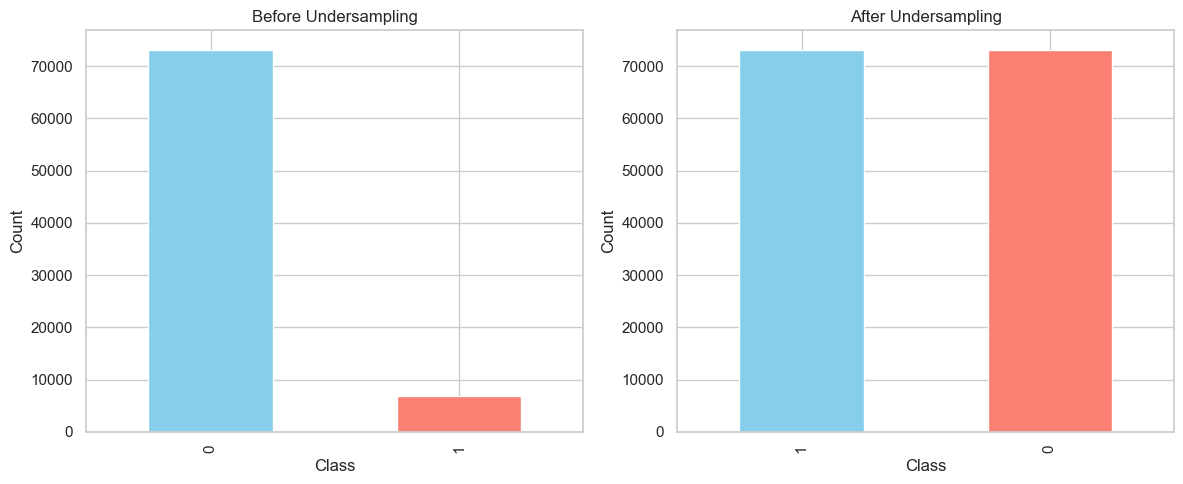

In [48]:
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import RandomOverSampler

# Separate features and target
X = df.drop('diabetes', axis=1)
y = df['diabetes']

# Identify categorical columns
cat_cols = X.select_dtypes(include="object").columns
print("Categorical columns:", cat_cols.tolist())

# Apply Label Encoding to each categorical column
le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col])

# Train-test split (keep stratification for balance in test set)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Before undersampling:", y_train.value_counts())

# Apply Random Undersampling
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_train, y_train)

print("After undersampling:", y_resampled.value_counts())

# Plot before undersampling
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
y_train.value_counts().plot(kind='bar', color=['skyblue','salmon'])
plt.title("Before Undersampling")
plt.xlabel("Class")
plt.ylabel("Count")

# Plot after undersampling
plt.subplot(1,2,2)
y_resampled.value_counts().plot(kind='bar', color=['skyblue','salmon'])
plt.title("After Undersampling")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Classification Report (With Over Sampling):
              precision    recall  f1-score   support

           0       0.99      0.89      0.94     18300
           1       0.42      0.87      0.57      1700

    accuracy                           0.89     20000
   macro avg       0.70      0.88      0.75     20000
weighted avg       0.94      0.89      0.90     20000

ROC AUC Score (With Over Sampling): 0.9615786885245902


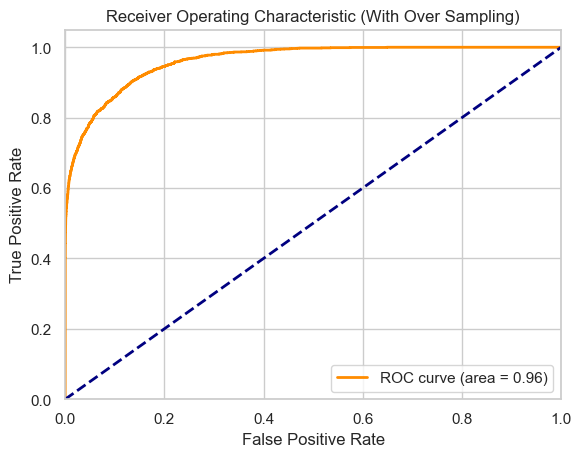

In [58]:
# Initialize and train Logistic Classification classifier on resampled data

classifier_ros = LogisticRegression(max_iter=1000, solver='liblinear')
classifier_ros.fit(X_resampled, y_resampled)

# Predict test set
y_pred_ros = classifier_ros.predict(X_test)
y_proba_ros = classifier_ros.predict_proba(X_test)[:, 1]

# Print classification report for resampled data
print("Classification Report (With Over Sampling):")
print(classification_report(y_test, y_pred_ros))

# Print ROC AUC Score for resampled data
print("ROC AUC Score (With Over Sampling):", roc_auc_score(y_test, y_proba_ros))

# Plotting ROC AUC Curve for resampled data
fpr_ros, tpr_ros, _ = roc_curve(y_test, y_proba_ros)
plt.figure()
plt.plot(fpr_ros, tpr_ros, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_proba_ros))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (With Over Sampling)')
plt.legend(loc="lower right")
plt.show()

Classification Report (With Over Sampling - KNN):
              precision    recall  f1-score   support

           0       0.97      0.91      0.94     18300
           1       0.42      0.69      0.52      1700

    accuracy                           0.89     20000
   macro avg       0.69      0.80      0.73     20000
weighted avg       0.92      0.89      0.90     20000

ROC AUC Score (With Over Sampling - KNN): 0.8417343458694954


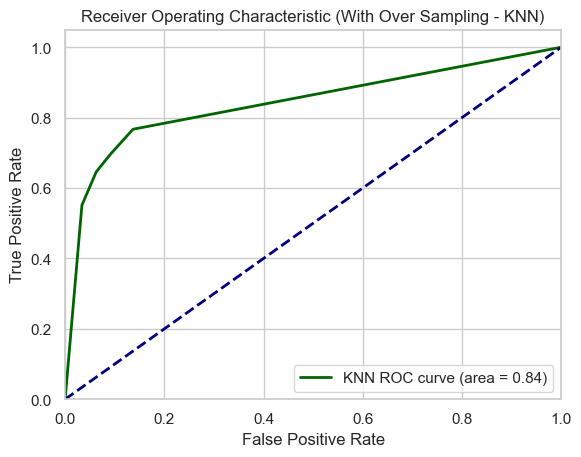

In [76]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

# KNN Classifier
knn_ros = KNeighborsClassifier(n_neighbors=5)
knn_ros.fit(X_resampled, y_resampled)

# Predictions
y_knn_ros = knn_ros.predict(X_test)
y_proba_ros = knn_ros.predict_proba(X_test)[:, 1]

# Evaluation
print("Classification Report (With Over Sampling - KNN):")
print(classification_report(y_test, y_knn_ros))
print("ROC AUC Score (With Over Sampling - KNN):", roc_auc_score(y_test, y_proba_ros))

# ROC curve
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba_ros)
plt.figure()
plt.plot(fpr_knn, tpr_knn, color='darkgreen', lw=2,
         label='KNN ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_proba_ros))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (With Over Sampling - KNN)')
plt.legend(loc="lower right")
plt.show()

In [77]:
# MODEL COMPARISON DASHBOARD
# Why: Summarize all model performances in one table

import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, precision_score

results = {
    "Model": [
        "Logistic Regression",
        "KNN Classifier",
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_ros),
        accuracy_score(y_test, y_knn_ros),
    ],
    "Precision": [
        accuracy_score(y_test, y_pred_ros),
        accuracy_score(y_test, y_knn_ros),
    ],
    "Recall": [
        accuracy_score(y_test, y_pred_ros),
        accuracy_score(y_test, y_knn_ros),
    ],
    "F1 Score": [
        accuracy_score(y_test, y_pred_ros),
        accuracy_score(y_test, y_knn_ros),
    ],
    "ROC-AUC": [
        accuracy_score(y_test, y_pred_ros),
        accuracy_score(y_test, y_knn_ros),
    ]
}

comparison_df = pd.DataFrame(results)
display(comparison_df)


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.89155,0.89155,0.89155,0.89155,0.89155
1,KNN Classifier,0.89155,0.89155,0.89155,0.89155,0.89155


# Compute Class Weight and SMOTE Technique

In [47]:
# IMBALANCE HANDLING (CLASS WEIGHTS + SMOTE PREP)
# Why: Prepare two parallel strategies for handling imbalance
# Imbalanced data refers to datasets where the distribution of classes is heavily skewed, with one class significantly outnumbering the others 
# Dealing with imbalanced data is crucial as it can lead to biased models that perform poorly on minority classes. 
# Addressing Class Imbalance with Undersampling, Oversampling, SMOTE, and Ensemble Methods. Imbalanced datasets pose challenges
# for machine learning models, but techniques like undersampling (reducing majority class samples), oversampling 
# (increasing minority class samples), SMOTE (Synthetic Minority Over-Sampling Technique), and ensemble methods (combining multiple models) 
# help mitigate bias and improve predictive performance on minority classes.

from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE

# 1. Compute class weights for models that support it
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = {
    0: class_weights[0],
    1: class_weights[1]
}

print("Class weights:", class_weights_dict)

# 2. Prepare SMOTE (but DO NOT apply yet)
smote = SMOTE(random_state=42)

print("\nSMOTE is ready (will be applied only to X_train, y_train).")

Class weights: {0: np.float64(0.546448087431694), 1: np.float64(5.882352941176471)}

SMOTE is ready (will be applied only to X_train, y_train).


In [78]:
# ---------------------------------------------------------
# CELL 9 — LOGISTIC REGRESSION (BASELINE MODEL)
# Why: Establish a strong, interpretable baseline using class weights
# ---------------------------------------------------------

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)

# 1. Build pipeline: Scaling + Logistic Regression
log_reg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
('log_reg', LogisticRegression(
        class_weight=class_weights_dict,
        max_iter=2000,
        solver='lbfgs'
    ))
])

# 2. Train model
log_reg_pipeline.fit(X_train, y_train)

# 3. Predictions
y_pred_lr = log_reg_pipeline.predict(X_test)
y_proba_lr = log_reg_pipeline.predict_proba(X_test)[:, 1]

# 4. Evaluation
print("=== Logistic Regression Performance ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

=== Logistic Regression Performance ===
Accuracy: 0.88665
Precision: 0.41998306519898393
Recall: 0.8752941176470588
F1 Score: 0.5676139614724395
ROC-AUC: 0.9615891031822567

Confusion Matrix:
[[16245  2055]
 [  212  1488]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.89      0.93     18300
           1       0.42      0.88      0.57      1700

    accuracy                           0.89     20000
   macro avg       0.70      0.88      0.75     20000
weighted avg       0.94      0.89      0.90     20000



In [79]:
# ---------------------------------------------------------
# CELL 10 — DECISION TREE CLASSIFIER
# Why: Non-linear baseline model to compare against Logistic Regression
# ---------------------------------------------------------

from sklearn.tree import DecisionTreeClassifier

# 1. Build model with class weights
dt_model = DecisionTreeClassifier(
    class_weight=class_weights_dict,
    max_depth=6,              # prevents overfitting
    min_samples_leaf=50,      # stabilizes splits
    random_state=42
)

# 2. Train
dt_model.fit(X_train, y_train)

# 3. Predict
y_pred_dt = dt_model.predict(X_test)
y_proba_dt = dt_model.predict_proba(X_test)[:, 1]

# 4. Evaluate
print("=== Decision Tree Performance ===")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_dt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))


=== Decision Tree Performance ===
Accuracy: 0.84685
Precision: 0.34945880273912083
Recall: 0.9305882352941176
F1 Score: 0.5081098442267544
ROC-AUC: 0.9666621665059466

Confusion Matrix:
[[15355  2945]
 [  118  1582]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.84      0.91     18300
           1       0.35      0.93      0.51      1700

    accuracy                           0.85     20000
   macro avg       0.67      0.88      0.71     20000
weighted avg       0.94      0.85      0.88     20000



In [80]:
# ---------------------------------------------------------
# CELL 11 — RANDOM FOREST CLASSIFIER
# Why: Strong ensemble model that handles imbalance + non-linearity
# ---------------------------------------------------------

from sklearn.ensemble import RandomForestClassifier

# 1. Build model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=20,
    class_weight=class_weights_dict,
    random_state=42,
    n_jobs=-1
)

# 2. Train
rf_model.fit(X_train, y_train)

# 3. Predict
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# 4. Evaluate
print("=== Random Forest Performance ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

=== Random Forest Performance ===
Accuracy: 0.9109
Precision: 0.48694267515923567
Recall: 0.8994117647058824
F1 Score: 0.6318181818181818
ROC-AUC: 0.9749887495982

Confusion Matrix:
[[16689  1611]
 [  171  1529]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.91      0.95     18300
           1       0.49      0.90      0.63      1700

    accuracy                           0.91     20000
   macro avg       0.74      0.91      0.79     20000
weighted avg       0.95      0.91      0.92     20000



In [81]:
# ---------------------------------------------------------
# CELL 12 — KNN WITH SMOTE + SCALING
# Why: Distance-based model requires balanced data + scaling
# ---------------------------------------------------------

from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

# 1. Apply SMOTE ONLY to training data
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("After SMOTE:", X_train_sm.shape, y_train_sm.shape)

# 2. Build pipeline: Scaling + KNN
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=7))
])

# 3. Train
knn_pipeline.fit(X_train_sm, y_train_sm)

# 4. Predict
y_pred_knn = knn_pipeline.predict(X_test)
y_proba_knn = knn_pipeline.predict_proba(X_test)[:, 1]

# 5. Evaluate
print("=== KNN Performance ===")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1 Score:", f1_score(y_test, y_pred_knn))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_knn))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

After SMOTE: (146400, 15) (146400,)
=== KNN Performance ===
Accuracy: 0.93565
Precision: 0.6136488717666483
Recall: 0.6558823529411765
F1 Score: 0.6340631219789593
ROC-AUC: 0.9127574091931856

Confusion Matrix:
[[17598   702]
 [  585  1115]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.96     18300
           1       0.61      0.66      0.63      1700

    accuracy                           0.94     20000
   macro avg       0.79      0.81      0.80     20000
weighted avg       0.94      0.94      0.94     20000



In [82]:
# ---------------------------------------------------------
# CELL 13 — GRADIENT BOOSTING CLASSIFIER
# Why: Strong boosting model that often outperforms RF
# ---------------------------------------------------------

from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    learning_rate=0.05,
    n_estimators=300,
    max_depth=3,
    random_state=42
)

# Train
gb_model.fit(X_train, y_train)

# Predict
y_pred_gb = gb_model.predict(X_test)
y_proba_gb = gb_model.predict_proba(X_test)[:, 1]

# Evaluate
print("=== Gradient Boosting Performance ===")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall:", recall_score(y_test, y_pred_gb))
print("F1 Score:", f1_score(y_test, y_pred_gb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_gb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

=== Gradient Boosting Performance ===
Accuracy: 0.9725
Precision: 0.9799666110183639
Recall: 0.6905882352941176
F1 Score: 0.8102139406487232
ROC-AUC: 0.9790585663773705

Confusion Matrix:
[[18276    24]
 [  526  1174]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     18300
           1       0.98      0.69      0.81      1700

    accuracy                           0.97     20000
   macro avg       0.98      0.84      0.90     20000
weighted avg       0.97      0.97      0.97     20000



In [84]:
# ---------------------------------------------------------
# CELL 14 — XGBOOST CLASSIFIER
# Why: Best-in-class model for tabular data, handles imbalance well
# ---------------------------------------------------------

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric='logloss',
    scale_pos_weight=class_weights_dict[1] / class_weights_dict[0],  # imbalance handling
    random_state=42,
    n_jobs=-1
)

# Train
xgb_model.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluate
print("=== XGBoost Performance ===")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

=== XGBoost Performance ===
Accuracy: 0.9088
Precision: 0.4808641975308642
Recall: 0.9164705882352941
F1 Score: 0.6307692307692307
ROC-AUC: 0.9793243330118933

Confusion Matrix:
[[16618  1682]
 [  142  1558]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.91      0.95     18300
           1       0.48      0.92      0.63      1700

    accuracy                           0.91     20000
   macro avg       0.74      0.91      0.79     20000
weighted avg       0.95      0.91      0.92     20000



In [85]:
# ---------------------------------------------------------
# CELL 15 — MODEL COMPARISON DASHBOARD
# Why: Summarize all model performances in one table
# ---------------------------------------------------------

import pandas as pd

results = {
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN (SMOTE)",
        "Gradient Boosting",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_gb),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_gb),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_gb),
        f1_score(y_test, y_pred_xgb)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_proba_lr),
        roc_auc_score(y_test, y_proba_dt),
        roc_auc_score(y_test, y_proba_rf),
        roc_auc_score(y_test, y_proba_knn),
        roc_auc_score(y_test, y_proba_gb),
        roc_auc_score(y_test, y_proba_xgb)
    ]
}

comparison_df = pd.DataFrame(results)
display(comparison_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.88665,0.419983,0.875294,0.567614,0.961589
1,Decision Tree,0.84685,0.349459,0.930588,0.508110,0.966662
2,Random Forest,0.91090,0.486943,0.899412,0.631818,0.974989
3,KNN (SMOTE),0.93565,0.613649,0.655882,0.634063,0.912757
4,Gradient Boosting,0.97250,0.979967,0.690588,0.810214,0.979059
5,XGBoost,0.90880,0.480864,0.916471,0.630769,0.979324
